# Step 3 & 4 — NLP Processing + LLM Integration

**Input:** `data/processed/articles_clean.csv`  
**Output:** `data/processed/articles_nlp_llm.csv`

| Stage | Technique | Library / Model |
|-------|-----------|----------------|
| NLP #1 | Named Entity Recognition (NER) | `spaCy` `en_core_web_sm` |
| NLP #2 | Sentiment Analysis | `transformers` · `cardiffnlp/twitter-roberta-base-sentiment-latest` |
| LLM | Credibility Scoring + Reasoning | Anthropic Claude API |


## 0. Install dependencies
```bash
pip install spacy transformers torch anthropic pandas tqdm matplotlib
python -m spacy download en_core_web_sm
```
You need to install Python 3.12 first.
Run once, then restart the kernel.

## 1. Imports & Configuration

In [8]:
import os
import json
import time
import ast
import warnings
import pandas as pd
import spacy
from transformers import pipeline as hf_pipeline
from tqdm.auto import tqdm
import anthropic

warnings.filterwarnings("ignore")
tqdm.pandas()

INPUT_CSV  = "../data/processed/articles_clean.csv"
OUTPUT_CSV = "../data/processed/articles_nlp_llm.csv"

# For NER  → original casing needed
TITLE_ORIG = "title"
DESC_ORIG  = "description"
# For sentiment → cleaned lowercase text produced by preprocessing
CLEAN_TEXT = "full_text"
DATE_COL   = "publishedAt"
SOURCE_COL = "source"     

# ── Anthropic config ───────────────────────────────────────────────────────────
ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY", "your-key-here")
LLM_MODEL         = "claude-sonnet-4-20250514"
LLM_MAX_TOKENS    = 512
LLM_DELAY_SECONDS = 0.5     # pause between API calls to avoid rate limits

print("Configuration loaded ✓")

Configuration loaded ✓


## 2. Load & Inspect Data

In [9]:
df = pd.read_csv(INPUT_CSV)

print(f"Rows loaded     : {len(df)}")
print(f"Columns present : {df.columns.tolist()}")
print(f"\nNull values per column:")
print(df.isnull().sum().to_string())

# ── Parse source column (stored as string-dict by pandas) ─────────────────────
def parse_source_name(src):
    try:
        d = ast.literal_eval(str(src))
        return d.get("name", "Unknown")
    except Exception:
        return str(src)

df["source_name"] = df[SOURCE_COL].apply(parse_source_name)

# ── Build NER input: original title + description (keeps casing & punctuation) ─
df["ner_input"] = (
    df[TITLE_ORIG].fillna("") + ". " + df[DESC_ORIG].fillna("")
).str.strip()

# Drop rows with no usable cleaned text
df = df.dropna(subset=[CLEAN_TEXT]).reset_index(drop=True)
df = df[df[CLEAN_TEXT].str.len() > 10].reset_index(drop=True)

print(f"\nRows after validation: {len(df)}")
df[["source_name", TITLE_ORIG, CLEAN_TEXT, DATE_COL]].head(3)

Rows loaded     : 29
Columns present : ['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content', 'title_clean', 'description_clean', 'full_text']

Null values per column:
source               0
author               1
title                0
description          0
url                  0
urlToImage           0
publishedAt          0
content              0
title_clean          0
description_clean    0
full_text            0

Rows after validation: 29


,source_name,title,full_text,publishedAt
0,The New York Review of Books,The Sage of Washington,the sage of washington walter lippmann was the...,2026-05-07
1,Khabarhub.com,Today’s News in a Nutshell,todays news in a nutshell kathmandu khabarhub ...,2026-05-04
2,Skeptic.com,Conspiracy Inc.: The New Media Disorder,conspiracy inc the new media disorder ashley r...,2026-05-03


---
## 3. NLP Technique #1 — Named Entity Recognition (NER)

We use **spaCy** (`en_core_web_sm`) on the **original, uncleaned** title + description.

Why original text and not `full_text`?  
The `clean_text()` function in `data_processing.ipynb` calls `text.lower()` which destroys capitalisation. NER models rely on capitalisation to distinguish `trump` (a verb) from `Trump` (a person). Using `full_text` would miss most named entities.

Entity types tracked:

| Label | Meaning | Example |
|-------|---------|--------|
| `PERSON` | Politicians, public figures | *Joe Biden* |
| `ORG` | Parties, media, institutions | *CNN, FBI, NATO* |
| `GPE` | Countries, cities, states | *Russia, Washington* |
| `EVENT` | Named events | *2026 Election* |
| `NORP` | Nationalities / political groups | *Republican, Democrat* |

In [10]:
print("Loading spaCy model (en_core_web_sm)...")
nlp = spacy.load("en_core_web_sm")

ENTITY_TYPES = {"PERSON", "ORG", "GPE", "EVENT", "NORP"}

def extract_entities(text: str) -> dict:
    """
    Run spaCy NER on original-cased text.
    Returns per-type entity lists and a total count.
    """
    empty = {
        "ner_persons": [], "ner_orgs": [], "ner_locations": [],
        "ner_events": [], "ner_groups": [], "ner_all": [], "ner_count": 0
    }
    if not isinstance(text, str) or not text.strip():
        return empty

    doc    = nlp(text[:1000])   
    by_type = {t: [] for t in ENTITY_TYPES}

    for ent in doc.ents:
        if ent.label_ in ENTITY_TYPES:
            clean_ent = ent.text.strip()
            if clean_ent:
                by_type[ent.label_].append(clean_ent)

    for k in by_type:
        by_type[k] = list(dict.fromkeys(by_type[k]))  

    all_ents = [e for lst in by_type.values() for e in lst]

    return {
        "ner_persons"  : by_type["PERSON"],
        "ner_orgs"     : by_type["ORG"],
        "ner_locations": by_type["GPE"],
        "ner_events"   : by_type["EVENT"],
        "ner_groups"   : by_type["NORP"],
        "ner_all"      : all_ents,
        "ner_count"    : len(all_ents),
    }

print("spaCy loaded ✓")


sample = "President Biden and NATO leaders met in Washington D.C. to discuss Russian disinformation campaigns."
result = extract_entities(sample)
print(f"\nSample: {sample}")
for k, v in result.items():
    if v:
        print(f"  {k:16s}: {v}")

Loading spaCy model (en_core_web_sm)...
spaCy loaded ✓

Sample: President Biden and NATO leaders met in Washington D.C. to discuss Russian disinformation campaigns.
  ner_persons     : ['Biden']
  ner_orgs        : ['NATO']
  ner_locations   : ['Washington D.C.']
  ner_groups      : ['Russian']
  ner_all         : ['Biden', 'NATO', 'Russian', 'Washington D.C.']
  ner_count       : 4


In [11]:
print(f"Running NER on {len(df)} articles...")

ner_results = df["ner_input"].progress_apply(extract_entities)
ner_df = pd.DataFrame(ner_results.tolist())

for col in ["ner_persons", "ner_orgs", "ner_locations", "ner_events", "ner_groups", "ner_all"]:
    ner_df[col] = ner_df[col].apply(json.dumps)

# Drop NER columns if they already exist in df (prevents duplicates)
ner_cols = ner_df.columns.tolist()
df = df.drop(columns=[c for c in ner_cols if c in df.columns])

df = pd.concat([df.reset_index(drop=True), ner_df.reset_index(drop=True)], axis=1)

print(f"NER done ✓")
print(f"  Avg entities per article : {df['ner_count'].mean():.1f}")
print(f"  Articles with ≥1 entity  : {(df['ner_count'] > 0).sum()}/{len(df)}")
df[[TITLE_ORIG, "ner_persons", "ner_orgs", "ner_locations", "ner_count"]].head(5)

Running NER on 29 articles...


  0%|          | 0/29 [00:00<?, ?it/s]

NER done ✓
  Avg entities per article : 3.5
  Articles with ≥1 entity  : 26/29


,title,ner_persons,ner_orgs,ner_locations,ner_count
0,The Sage of Washington,"[""Walter Lippmann""]",[],"[""Washington""]",2
1,Today’s News in a Nutshell,"[""Nutshell"", ""KATHMANDU"", ""Khabarhub"", ""Con""]",[],"[""Nepal""]",5
2,Conspiracy Inc.: The New Media Disorder,"[""Ashley Rindsberg"", ""Tucker Carlson"", ""Candac...",[],[],3
3,"News24 | Lizette Rabe | In 2026, the fight for...","[""Lizette Rabe""]",[],"[""Truth""]",3
4,"Staged? Why Conspiracy Theories Are Stupid, bu...","[""Cole Tomas Allen""]","[""Bad Politics""]",[],2


---
## 4. NLP Technique #2 — Sentiment Analysis

We use **`cardiffnlp/twitter-roberta-base-sentiment-latest`** — a RoBERTa model fine-tuned on ~124M tweets.

Why this model for news articles?  
The articles in this dataset (Skeptic.com, News24, MobileSyrup, Fair Observer) have short, punchy descriptions similar in register to social-media text. This model handles that style well and is robust to lowercase, punctuation-free input — which is exactly what the preprocessing step produced in `full_text`.

Output per article:
- `sentiment_label` — dominant class: `Positive`, `Neutral`, `Negative`
- `sentiment_score` — confidence of that class (0–1)
- Raw scores for all three classes (numeric features for downstream use)

In [12]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
print(f"Loading: {SENTIMENT_MODEL}")
print("First run downloads ~500 MB — subsequent runs use local cache.")

sentiment_pipe = hf_pipeline(
    task="sentiment-analysis",
    model=SENTIMENT_MODEL,
    tokenizer=SENTIMENT_MODEL,
    top_k=None,
    truncation=True,
    max_length=512,
)

print("Sentiment model loaded ✓")

tests = [
    "conspiracy inc the new media disorder ashley rindsberg traces how the collapse of trusted institutions",
    "fake youtube videos promoting us annexation seize canadian viewers",
    "truth is the first casualty of war and were living through an information crisis",
]
print("\nSanity checks (lowercase cleaned text):")
for t in tests:
    scores = sentiment_pipe(t)[0]
    best   = max(scores, key=lambda x: x["score"])
    print(f"  [{best['label']:8s} {best['score']:.2f}] {t[:65]}...")

Loading: cardiffnlp/twitter-roberta-base-sentiment-latest
First run downloads ~500 MB — subsequent runs use local cache.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentiment model loaded ✓

Sanity checks (lowercase cleaned text):
  [neutral  0.55] conspiracy inc the new media disorder ashley rindsberg traces how...
  [negative 0.76] fake youtube videos promoting us annexation seize canadian viewer...
  [negative 0.85] truth is the first casualty of war and were living through an inf...


In [13]:
def analyze_sentiment(text: str) -> dict:
    """Return dominant sentiment label + per-class scores."""
    if not isinstance(text, str) or not text.strip():
        return {"sentiment_label": None, "sentiment_score": None,
                "sentiment_positive": None, "sentiment_neutral": None,
                "sentiment_negative": None}
    results = sentiment_pipe(text[:512])[0]
    scores  = {r["label"]: round(r["score"], 4) for r in results}
    best    = max(results, key=lambda x: x["score"])
    return {
        "sentiment_label"    : best["label"],
        "sentiment_score"    : round(best["score"], 4),
        "sentiment_positive" : scores.get("Positive", 0.0),
        "sentiment_neutral"  : scores.get("Neutral",  0.0),
        "sentiment_negative" : scores.get("Negative", 0.0),
    }

print(f"Running sentiment analysis on {len(df)} articles (using full_text column)...")
sent_results = df[CLEAN_TEXT].progress_apply(analyze_sentiment)
sent_df      = pd.json_normalize(sent_results)
df           = pd.concat([df, sent_df], axis=1)

print("Sentiment done ✓")
print("\nSentiment distribution:")
print(df["sentiment_label"].value_counts().to_string())

df[[TITLE_ORIG, "sentiment_label", "sentiment_score"]].head(5)

Running sentiment analysis on 29 articles (using full_text column)...


  0%|          | 0/29 [00:00<?, ?it/s]

Sentiment done ✓

Sentiment distribution:
sentiment_label
neutral     15
negative    12
positive     2


,title,sentiment_label,sentiment_score
0,The Sage of Washington,neutral,0.7772
1,Today’s News in a Nutshell,neutral,0.8162
2,Conspiracy Inc.: The New Media Disorder,neutral,0.6625
3,"News24 | Lizette Rabe | In 2026, the fight for...",neutral,0.5171
4,"Staged? Why Conspiracy Theories Are Stupid, bu...",negative,0.7981


---
## 5. LLM Integration — Credibility Scoring with Claude

Each article is sent to **Claude** with a structured prompt that includes:
- Source outlet + publication date
- Original title + description (not the cleaned version — more context for the model)
- Named entities extracted by NER
- Sentiment label from step 4

Claude responds with a structured JSON assessment:

```json
{
  "credibility_score": 6,
  "misinformation_risk": "medium",
  "red_flags": ["no primary source cited", "emotionally charged language"],
  "reasoning": "The article frames the event accurately but omits key counterevidence."
}
```

In [14]:
from groq import Groq
from dotenv import load_dotenv, find_dotenv
import re


load_dotenv(find_dotenv(), override=True)
GROQ_API_KEY = os.environ.get("GROQ_API_KEY")

client = Groq(api_key=GROQ_API_KEY)
LLM_MODEL = "llama-3.3-70b-versatile"  

SYSTEM_PROMPT = """\
You are a fact-checking assistant specialising in political misinformation in news media.
You receive a news article snippet and NLP metadata, and assess its credibility.

Respond ONLY with a valid JSON object — no markdown fences, no preamble — in this schema:
{
  "credibility_score": <integer 0-10>,
  "misinformation_risk": <"low" | "medium" | "high">,
  "red_flags": [<string>, ...],
  "reasoning": <one concise sentence>
}

Scoring guide:
8-10 → Factual, verifiable, balanced reporting
5-7  → Mostly accurate but missing sources, slightly exaggerated, or one-sided
2-4  → Misleading framing, unverified claims, cherry-picked data
0-1  → Fabricated quotes, conspiracy rhetoric, clear misinformation

Red flag examples: "no source cited", "emotionally loaded language",
"unverified statistic", "misleading headline vs body", "anonymous sources only".
"""

def build_prompt(row: pd.Series) -> str:
    persons = json.loads(row.get("ner_persons",  "[]"))
    orgs    = json.loads(row.get("ner_orgs",     "[]"))
    locs    = json.loads(row.get("ner_locations","[]"))
    groups  = json.loads(row.get("ner_groups",   "[]"))

    return f"""\
SOURCE  : {row.get('source_name', 'Unknown')}
DATE    : {row.get(DATE_COL, 'Unknown')}
TITLE   : {row.get(TITLE_ORIG, '')}
SNIPPET : {row.get(DESC_ORIG,  '')}

NLP METADATA:
  Sentiment     : {row.get('sentiment_label', 'N/A')} (confidence {row.get('sentiment_score', 'N/A')})
  Persons       : {persons or 'none detected'}
  Organisations : {orgs    or 'none detected'}
  Locations     : {locs    or 'none detected'}
  Pol. groups   : {groups  or 'none detected'}
  Total entities: {row.get('ner_count', 0)}

Assess the credibility and misinformation risk of this article.
"""

def score_credibility(row: pd.Series) -> dict:
    try:
        resp = client.chat.completions.create(
            model=LLM_MODEL,
            max_tokens=LLM_MAX_TOKENS,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": build_prompt(row)},
            ],
        )
        raw = resp.choices[0].message.content.strip()
        
 
        raw = re.sub(r"```json\s*", "", raw)
        raw = re.sub(r"```\s*", "", raw)
        

        match = re.search(r"\{.*\}", raw, re.DOTALL)
        if match:
            raw = match.group(0)
        
        parsed = json.loads(raw)
        return {
            "llm_credibility_score": parsed.get("credibility_score"),
            "llm_misinfo_risk"     : parsed.get("misinformation_risk"),
            "llm_red_flags"        : json.dumps(parsed.get("red_flags", [])),
            "llm_reasoning"        : parsed.get("reasoning", ""),
            "llm_error"            : None,
        }
    except json.JSONDecodeError as e:
        return {"llm_credibility_score": None, "llm_misinfo_risk": None,
                "llm_red_flags": "[]", "llm_reasoning": "",
                "llm_error": f"JSON parse error: {e}"}
    except Exception as e:
        return {"llm_credibility_score": None, "llm_misinfo_risk": None,
                "llm_red_flags": "[]", "llm_reasoning": "",
                "llm_error": str(e)}

print("Groq client ready ✓")
print("\nSanity check — prompt for article 0:")
print(build_prompt(df.iloc[0]))
print("\nRunning LLM call...")
test = score_credibility(df.iloc[0])

Groq client ready ✓

Sanity check — prompt for article 0:
SOURCE  : The New York Review of Books
DATE    : 2026-05-07
TITLE   : The Sage of Washington
SNIPPET : Walter Lippmann was the most influential political commentator of his generation, but behind his preternatural confidence was a far more complicated and unsettled character.

NLP METADATA:
  Sentiment     : neutral (confidence 0.7772)
  Persons       : ['Walter Lippmann']
  Organisations : none detected
  Locations     : ['Washington']
  Pol. groups   : none detected
  Total entities: 2

Assess the credibility and misinformation risk of this article.


Running LLM call...


In [15]:
est_min = len(df) * (LLM_DELAY_SECONDS + 1.5) / 60
print(f"Running LLM scoring on {len(df)} articles (~{est_min:.1f} min estimated)...")

llm_results = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Groq scoring"):
    llm_results.append(score_credibility(row))
    time.sleep(LLM_DELAY_SECONDS)

llm_df = pd.json_normalize(llm_results)

llm_cols = llm_df.columns.tolist()
df = df.drop(columns=[c for c in llm_cols if c in df.columns])

df = pd.concat([df.reset_index(drop=True), llm_df.reset_index(drop=True)], axis=1)

errors = df["llm_error"].notna().sum()
print(f"\nDone ✓  |  Errors: {errors}/{len(df)}")
print("\nMisinformation risk distribution:")
print(df["llm_misinfo_risk"].value_counts().to_string())
print(f"\nMean credibility score: {df['llm_credibility_score'].mean():.2f} / 10")


Running LLM scoring on 29 articles (~1.0 min estimated)...


Groq scoring:   0%|          | 0/29 [00:00<?, ?it/s]


Done ✓  |  Errors: 6/29

Misinformation risk distribution:
llm_misinfo_risk
low       18
medium     5

Mean credibility score: 7.70 / 10


---
## 6. Results

In [16]:
print("=" * 72)
print("FULL PIPELINE RESULTS — SAMPLE")
print("=" * 72)

for _, row in df.head(5).iterrows():
    print(f"\nSOURCE    : {row.get('source_name')}  ({row.get(DATE_COL)})")
    print(f"TITLE     : {str(row.get(TITLE_ORIG, ''))[:90]}")
    print(f"NER       : {row.get('ner_count')} entities | persons={row.get('ner_persons')} | orgs={row.get('ner_orgs')}")
    print(f"SENTIMENT : {row.get('sentiment_label')} ({row.get('sentiment_score')})")
    print(f"CREDIBILITY: {row.get('llm_credibility_score')}/10  risk={row.get('llm_misinfo_risk')}")
    print(f"RED FLAGS  : {row.get('llm_red_flags')}")
    print(f"REASONING  : {row.get('llm_reasoning')}")
    print("-" * 72)

FULL PIPELINE RESULTS — SAMPLE

SOURCE    : The New York Review of Books  (2026-05-07)
TITLE     : The Sage of Washington
NER       : 2 entities | persons=["Walter Lippmann"] | orgs=[]
SENTIMENT : neutral (0.7772)
CREDIBILITY: nan/10  risk=nan
RED FLAGS  : []
REASONING  : 
------------------------------------------------------------------------

SOURCE    : Khabarhub.com  (2026-05-04)
TITLE     : Today’s News in a Nutshell
NER       : 5 entities | persons=["Nutshell", "KATHMANDU", "Khabarhub", "Con"] | orgs=[]
SENTIMENT : neutral (0.8162)
CREDIBILITY: nan/10  risk=nan
RED FLAGS  : []
REASONING  : 
------------------------------------------------------------------------

SOURCE    : Skeptic.com  (2026-05-03)
TITLE     : Conspiracy Inc.: The New Media Disorder
NER       : 3 entities | persons=["Ashley Rindsberg", "Tucker Carlson", "Candace Owens"] | orgs=[]
SENTIMENT : neutral (0.6625)
CREDIBILITY: 8.0/10  risk=low
RED FLAGS  : []
REASONING  : The article snippet appears to be a neutral 

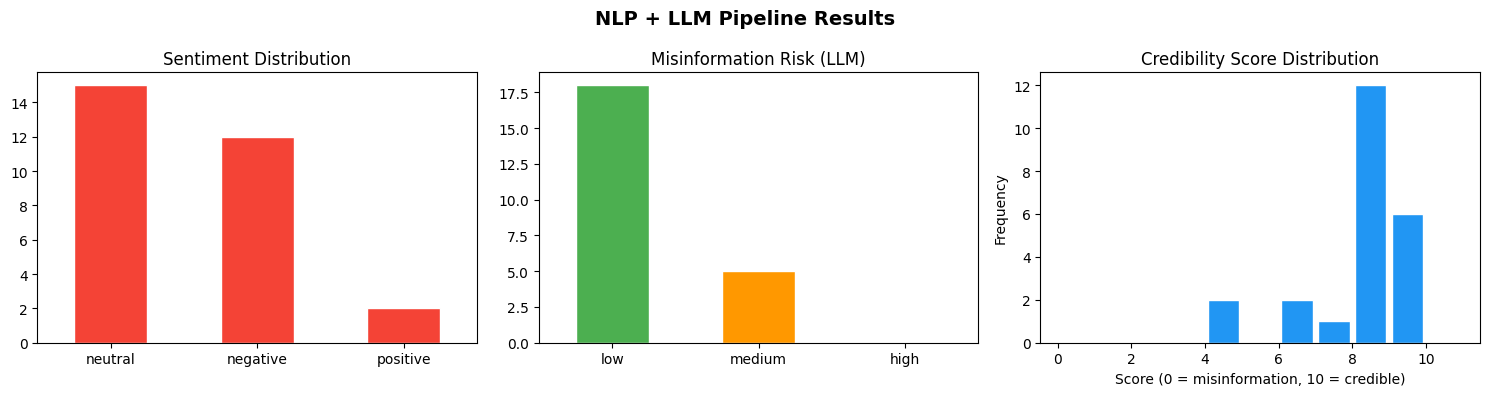

Chart saved → data/nlp_llm_summary.png


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("NLP + LLM Pipeline Results", fontsize=14, fontweight="bold")

# 1 — Sentiment distribution
sent_counts = df["sentiment_label"].value_counts()
colors_sent = [
    "#4CAF50" if l == "Positive" else "#9E9E9E" if l == "Neutral" else "#F44336"
    for l in sent_counts.index
]
sent_counts.plot(kind="bar", ax=axes[0], color=colors_sent, edgecolor="white")
axes[0].set_title("Sentiment Distribution")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# 2 — Misinformation risk
risk_order  = ["low", "medium", "high"]
risk_colors = {"low": "#4CAF50", "medium": "#FF9800", "high": "#F44336"}
risk_counts = df["llm_misinfo_risk"].value_counts().reindex(risk_order, fill_value=0)
risk_counts.plot(
    kind="bar", ax=axes[1],
    color=[risk_colors[k] for k in risk_counts.index],
    edgecolor="white"
)
axes[1].set_title("Misinformation Risk (LLM)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

# 3 — Credibility score histogram
df["llm_credibility_score"].dropna().astype(int).plot(
    kind="hist", bins=range(0, 12), ax=axes[2],
    color="#2196F3", edgecolor="white", rwidth=0.85
)
axes[2].set_title("Credibility Score Distribution")
axes[2].set_xlabel("Score (0 = misinformation, 10 = credible)")

plt.tight_layout()
os.makedirs("../data", exist_ok=True)
plt.savefig("../data/nlp_llm_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → data/nlp_llm_summary.png")

---
## 7. Save Output

In [18]:
os.makedirs("../data/processed", exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"Saved {len(df)} rows → {OUTPUT_CSV}")
print(f"Columns: {df.columns.tolist()}")

preview_cols = [
    "source_name", TITLE_ORIG, DATE_COL,
    "ner_persons", "ner_orgs", "ner_count",
    "sentiment_label", "sentiment_score",
    "llm_credibility_score", "llm_misinfo_risk", "llm_reasoning"
]
df[[c for c in preview_cols if c in df.columns]].head()

Saved 29 rows → ../data/processed/articles_nlp_llm.csv
Columns: ['source', 'author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content', 'title_clean', 'description_clean', 'full_text', 'source_name', 'ner_input', 'ner_persons', 'ner_orgs', 'ner_locations', 'ner_events', 'ner_groups', 'ner_all', 'ner_count', 'sentiment_label', 'sentiment_score', 'sentiment_positive', 'sentiment_neutral', 'sentiment_negative', 'llm_credibility_score', 'llm_misinfo_risk', 'llm_red_flags', 'llm_reasoning', 'llm_error']


,source_name,title,publishedAt,ner_persons,ner_orgs,ner_count,sentiment_label,sentiment_score,llm_credibility_score,llm_misinfo_risk,llm_reasoning
0,The New York Review of Books,The Sage of Washington,2026-05-07,"[""Walter Lippmann""]",[],2,neutral,0.7772,NaN,NaN,
1,Khabarhub.com,Today’s News in a Nutshell,2026-05-04,"[""Nutshell"", ""KATHMANDU"", ""Khabarhub"", ""Con""]",[],5,neutral,0.8162,NaN,NaN,
2,Skeptic.com,Conspiracy Inc.: The New Media Disorder,2026-05-03,"[""Ashley Rindsberg"", ""Tucker Carlson"", ""Candac...",[],3,neutral,0.6625,8.0,low,The article snippet appears to be a neutral su...
3,News24,"News24 | Lizette Rabe | In 2026, the fight for...",2026-05-02,"[""Lizette Rabe""]",[],3,neutral,0.5171,9.0,low,The article snippet appears to be a genuine op...
4,Fair Observer,"Staged? Why Conspiracy Theories Are Stupid, bu...",2026-05-01,"[""Cole Tomas Allen""]","[""Bad Politics""]",2,negative,0.7981,8.0,low,The article appears to be a factual report on ...


---
## 8. Output Schema Reference

All columns from `articles_clean.csv` are preserved. The following are added by this notebook:

| Column | Type | Added by | Description |
|--------|------|----------|-------------|
| `source_name` | str | this notebook | Parsed outlet name e.g. `News24` |
| `ner_input` | str | this notebook | Original title + description used for NER |
| `ner_persons` | JSON list | NLP #1 | PERSON entities |
| `ner_orgs` | JSON list | NLP #1 | ORG entities |
| `ner_locations` | JSON list | NLP #1 | GPE entities |
| `ner_events` | JSON list | NLP #1 | EVENT entities |
| `ner_groups` | JSON list | NLP #1 | NORP entities (political groups) |
| `ner_all` | JSON list | NLP #1 | All entities combined |
| `ner_count` | int | NLP #1 | Total entity count |
| `sentiment_label` | str | NLP #2 | `Positive` / `Neutral` / `Negative` |
| `sentiment_score` | float | NLP #2 | Confidence of dominant label (0–1) |
| `sentiment_positive` | float | NLP #2 | Raw positive score |
| `sentiment_neutral` | float | NLP #2 | Raw neutral score |
| `sentiment_negative` | float | NLP #2 | Raw negative score |
| `llm_credibility_score` | int | LLM | 0–10 credibility rating from Claude |
| `llm_misinfo_risk` | str | LLM | `low` / `medium` / `high` |
| `llm_red_flags` | JSON list | LLM | Specific concerns flagged |
| `llm_reasoning` | str | LLM | One-sentence explanation |
| `llm_error` | str/null | LLM | Error message if API call failed |

---
**Next step:** `articles_nlp_llm.csv` → deployment notebook (FastAPI endpoint)